In [13]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.base import TransformerMixin

In [24]:
# extract data from CSVs
data_dir = "snippets"
csv_files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))

rows = []
for f in csv_files:
    df = pd.read_csv(f, header=None)   # read 1-row csv with no header

    # flatten to a single row Series
    row = df.iloc[0].copy()

    # extract filename
    filename = os.path.basename(f).lower()
    #print(filename)

    # assign label
    if "unhealthy" in filename:
        label = 0
    elif "healthy" in filename:
        label = 1
    else:
        raise ValueError(f"Unknown label in filename: {filename}")

    # add label as last column
    row["label"] = label

    rows.append(row)

# combine all rows into one dataframe
master_df = pd.DataFrame(rows).reset_index(drop=True)

print(master_df.shape)

(60, 1081)


In [3]:
master_df

,0,1,2,3,4,5,6,7,8,9,...,1071,1072,1073,1074,1075,1076,1077,1078,1079,label
0,0.764612,2.229688,0.863398,0.093187,0.071045,1.062802,0.039689,0.269793,0.062081,0.758040,...,0.728558,2.033796,0.707090,0.094025,0.061396,1.052885,0.039689,0.275583,0.052382,1.0
1,0.212379,0.384375,0.165310,0.075089,0.051616,NaN,NaN,NaN,0.028159,0.205427,...,0.195675,0.384375,0.208679,0.075012,0.051616,NaN,NaN,NaN,0.037652,0.0
2,0.708792,1.985847,0.629675,0.093945,0.066214,NaN,NaN,NaN,0.071835,0.720949,...,0.774807,2.162622,0.708193,0.095064,0.066214,NaN,NaN,NaN,0.052382,1.0
3,0.197291,0.408498,0.219343,0.074783,0.051616,NaN,NaN,NaN,0.037652,0.206242,...,0.204601,0.394269,0.158208,0.076009,0.056389,NaN,NaN,NaN,0.028159,0.0
4,0.727979,2.116988,0.672173,0.095024,0.056593,NaN,NaN,NaN,0.066951,0.760438,...,NaN,NaN,NaN,0.095264,0.066214,NaN,NaN,NaN,0.071835,1.0
5,0.221848,0.404207,0.153139,0.075971,0.065976,NaN,NaN,NaN,0.028159,NaN,...,0.203382,0.357469,0.069660,0.074859,0.037379,NaN,NaN,NaN,0.037652,0.0
6,0.739707,2.127596,0.720422,0.094265,0.071045,NaN,NaN,NaN,0.042737,0.719802,...,0.722711,1.979776,0.623115,0.095184,0.066214,NaN,NaN,NaN,0.062081,1.0
7,0.193641,0.371799,0.076917,0.074438,0.046857,0.287671,0.183209,0.048643,0.032899,0.180791,...,0.205019,0.390497,0.146117,0.077816,0.061176,NaN,NaN,NaN,0.023433,0.0
8,0.718618,2.012222,0.616498,0.094304,0.032779,NaN,NaN,NaN,0.062081,0.723861,...,0.697811,1.913018,0.549030,0.095344,0.056593,NaN,NaN,NaN,0.052382,1.0
9,0.191626,0.388619,0.173998,0.078163,0.046857,0.323944,0.185661,0.042770,0.032899,0.202166,...,0.212791,0.408498,0.218967,0.076778,0.051616,0.330189,0.185170,0.034343,0.037652,0.0


In [20]:
y = master_df['label']
X = master_df.drop('label', axis=1).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
class RowPatternFill(TransformerMixin):
    def __init__(self, starts=range(0,9), step=9):
        self.starts = starts
        self.step = step

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # preserve DataFrame structure if possible
        X_filled = pd.DataFrame(X).copy()

        for start in self.starts:
            cols = X_filled.columns[start::self.step]
            X_filled.loc[:, cols] = X_filled.loc[:, cols].bfill(axis=1).ffill(axis=1)

        return X_filled


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=109)

model = Pipeline([
    ("fill", RowPatternFill(starts=range(0,9), step=9)),
    ("scale", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0, gamma="scale", random_state=109, probability=True))
])

# cross-validation accuracy on training set
cv_acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

print("CV accuracies:", cv_acc_scores)
print("Mean CV accuracy:", cv_acc_scores.mean())
print("Std CV accuracy:", cv_acc_scores.std())

# cross-validation ROC AUC on training set
cv_auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")

print("CV ROC AUC scores:", cv_auc_scores)
print("Mean CV ROC AUC:", cv_auc_scores.mean())
print("Std CV ROC AUC:", cv_auc_scores.std())

# fit final model on full training set
model.fit(X_train, y_train)

# test predictions
y_pred = model.predict(X_test)

# test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", test_acc)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

# test ROC AUC using decision scores
y_score = model.decision_function(X_test)
test_auc = roc_auc_score(y_test, y_score)
print("Test ROC AUC:", test_auc)

CV accuracies: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0
Std CV accuracy: 0.0
CV ROC AUC scores: [1. 1. 1. 1. 1.]
Mean CV ROC AUC: 1.0
Std CV ROC AUC: 0.0
Test accuracy: 1.0
Confusion matrix:
[[6 0]
 [0 6]]
Test ROC AUC: 1.0


In [6]:
import joblib

model.fit(X, y)
joblib.dump(model, "abrs_classifier.pkl")

['abrs_classifier.pkl']

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

sensor_map = {
    "ENS160_R1": 0,
    "ENS160_R2": 1,
    "ENS160_R3": 2,
    "SGP41": 3,
    "TGS2602": 4,
    "SCD_CO2": 5,
    "SCD2_T": 6,
    "SCD3_H": 7,
    "MQ3": 8
}

results = []

for sensor_name, start in sensor_map.items():
    X_sensor = X.iloc[:, start::9]

    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=1.0, random_state=42)
    )

    scores = cross_val_score(model, X_sensor, y, cv=cv, scoring="accuracy")

    results.append({
        "sensor": sensor_name,
        "n_features": X_sensor.shape[1],
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std(),
        "fold_scores": scores
    })

results_df = pd.DataFrame(results).sort_values("mean_cv_accuracy", ascending=False)
print(results_df[["sensor", "n_features", "mean_cv_accuracy", "std_cv_accuracy"]])

ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/admin/sinus/v1/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/admin/sinus/v1/.venv/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/admin/sinus/v1/.venv/lib/python3.11/site-packages/sklearn/pipeline.py", line 621, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/Users/admin/sinus/v1/.venv/lib/python3.11/site-packages/sklearn/base.py", line 1336

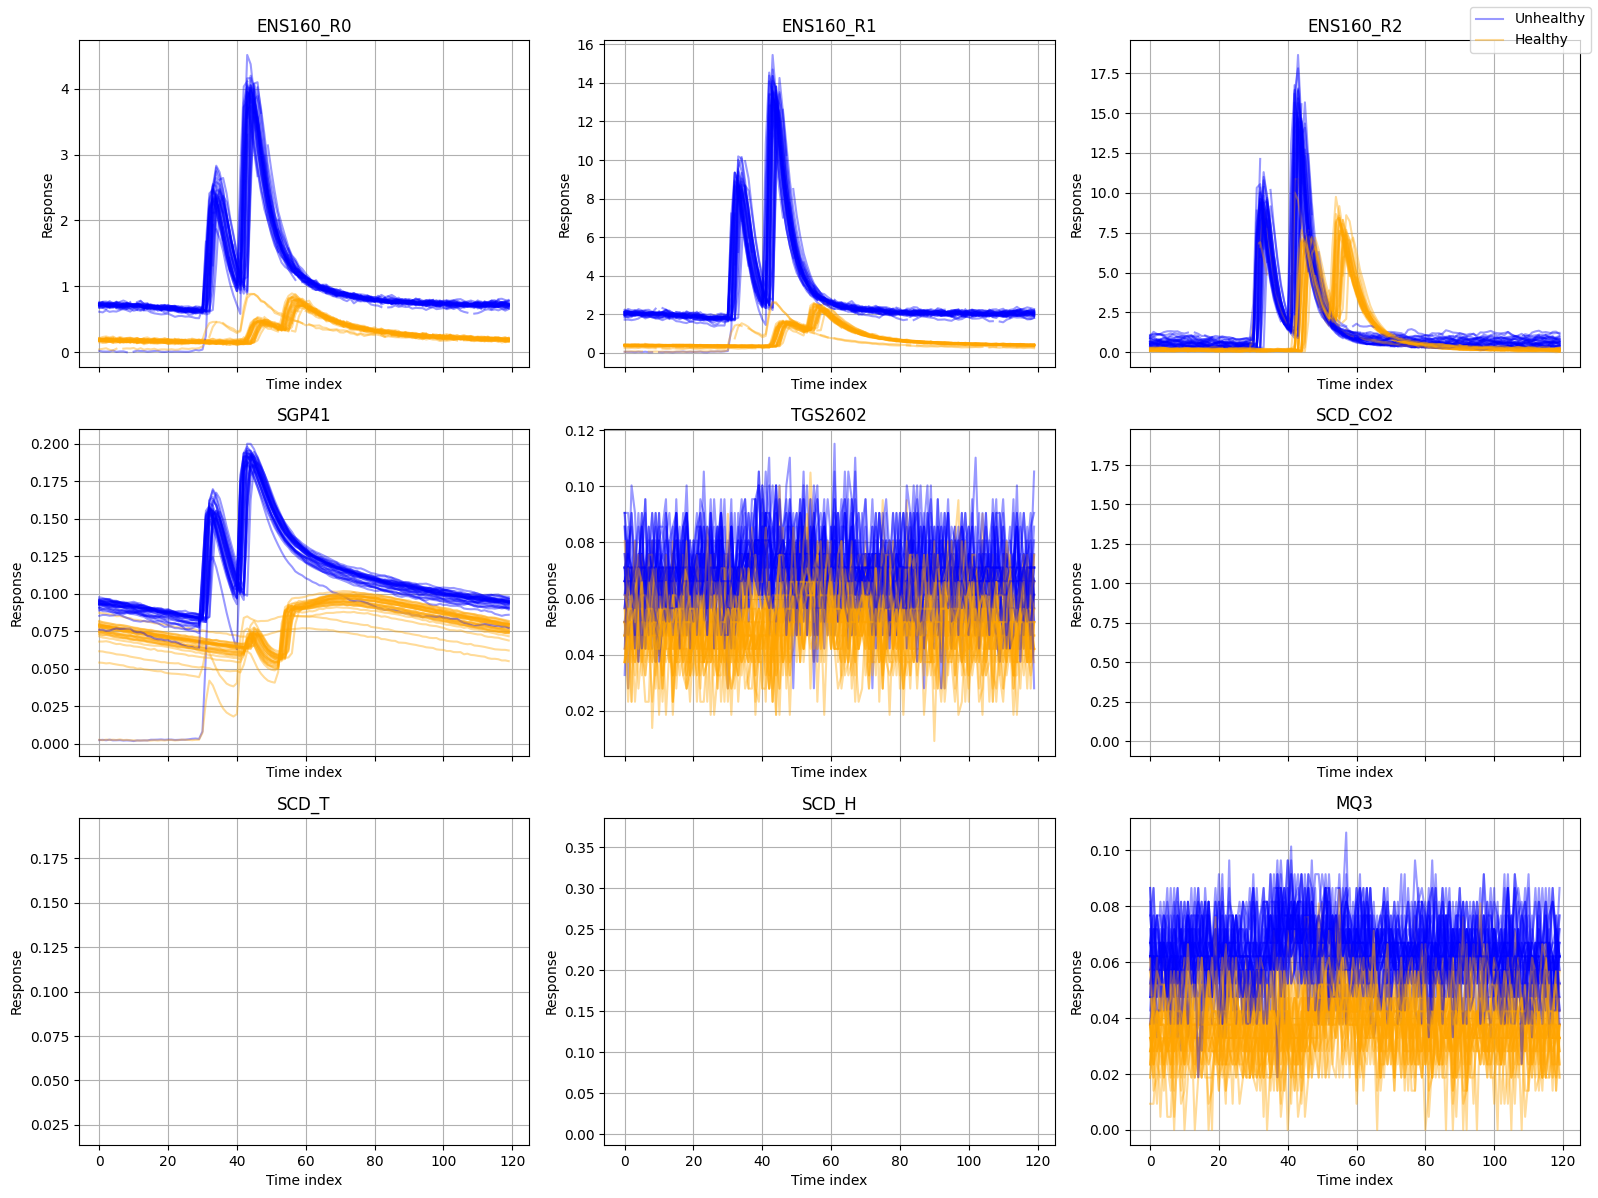

In [17]:
sensor_names = [
    "ENS160_R0", "ENS160_R1", "ENS160_R2",
    "SGP41", "TGS2602", "SCD_CO2",
    "SCD_T", "SCD_H", "MQ3"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)
axes = axes.flatten()

healthy_labeled = False
unhealthy_labeled = False

for sensor_idx in range(9):
    ax = axes[sensor_idx]
    X_sensor = X.iloc[:, sensor_idx::9]

    for sample_idx in range(len(X_sensor)):
        if y.iloc[sample_idx] == 0:
            ax.plot(
                X_sensor.iloc[sample_idx].values,
                color="orange",
                alpha=0.4,
                label="Healthy" if not healthy_labeled and sensor_idx == 0 else ""
            )
            if sensor_idx == 0:
                healthy_labeled = True
        else:
            ax.plot(
                X_sensor.iloc[sample_idx].values,
                color="blue",
                alpha=0.4,
                label="Unhealthy" if not unhealthy_labeled and sensor_idx == 0 else ""
            )
            if sensor_idx == 0:
                unhealthy_labeled = True

    ax.set_title(sensor_names[sensor_idx])
    ax.set_xlabel("Time index")
    ax.set_ylabel("Response")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()

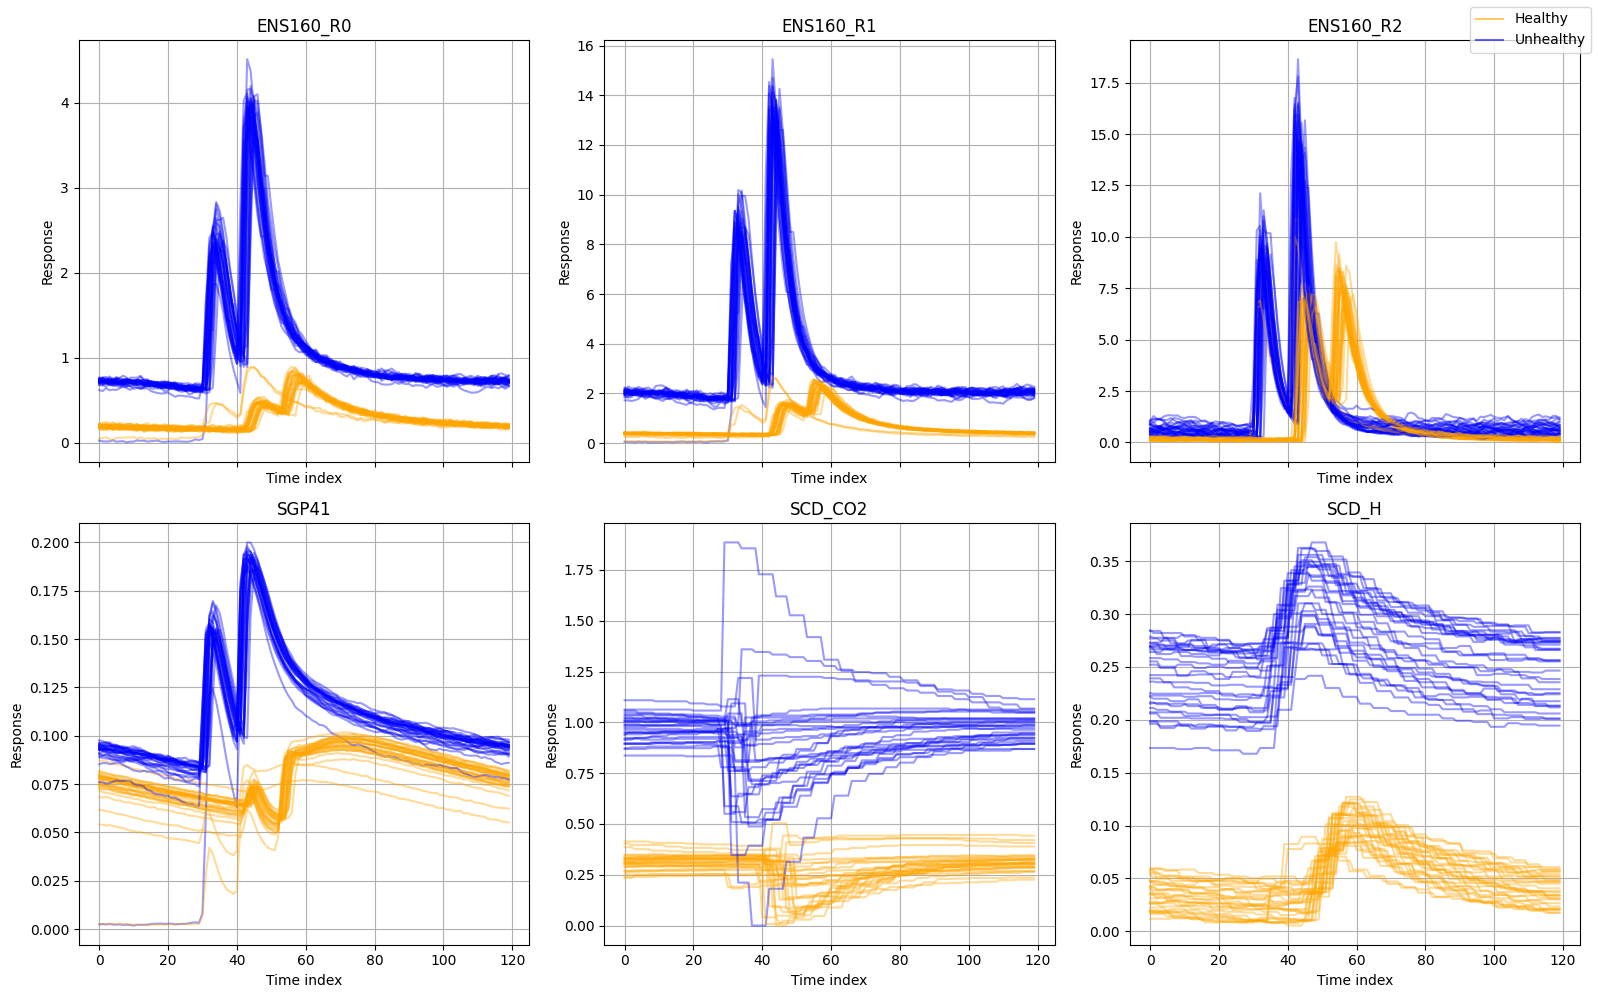

In [25]:
import matplotlib.pyplot as plt

# make a filled copy for plotting
X_plot = X.copy()

for start in [0, 1, 2, 5, 6, 7]:
    cols = X_plot.columns[start::9]
    X_plot.loc[:, cols] = X_plot.loc[:, cols].bfill(axis=1).ffill(axis=1)

sensor_indices = [0, 1, 2, 3, 5, 7]
sensor_names = [
    "ENS160_R0", "ENS160_R1", "ENS160_R2",
    "SGP41", "SCD_CO2", "SCD_H"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for plot_idx, sensor_idx in enumerate(sensor_indices):
    ax = axes[plot_idx]
    X_sensor = X_plot.iloc[:, sensor_idx::9]

    for sample_idx in range(len(X_sensor)):
        if y.iloc[sample_idx] == 0:
            ax.plot(X_sensor.iloc[sample_idx].values, color="orange", alpha=0.4)
        else:
            ax.plot(X_sensor.iloc[sample_idx].values, color="blue", alpha=0.4)

    ax.set_title(sensor_names[plot_idx])
    ax.set_xlabel("Time index")
    ax.set_ylabel("Response")
    ax.grid(True)

fig.legend(
    handles=[
        plt.Line2D([0], [0], color="orange", alpha=0.6, label="Healthy"),
        plt.Line2D([0], [0], color="blue", alpha=0.6, label="Unhealthy"),
    ],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [26]:
# CALCULATE COEFFICIENT OF VARIATION

# one scalar per row: overall signature magnitude
filler = RowPatternFill()
X_filled = filler.transform(X)
signature_metric = np.linalg.norm(X_filled.values, axis=1)

healthy_vals = signature_metric[y == 0]
unhealthy_vals = signature_metric[y == 1]

healthy_cv = np.std(healthy_vals, ddof=1) / np.mean(healthy_vals) * 100
unhealthy_cv = np.std(unhealthy_vals, ddof=1) / np.mean(unhealthy_vals) * 100
avg_cv = np.mean([healthy_cv, unhealthy_cv])

print("Healthy CV (%):", healthy_cv)
print("Unhealthy CV (%):", unhealthy_cv)
print("Average CV (%):", avg_cv)

Healthy CV (%): 6.186399945842772
Unhealthy CV (%): 4.400451534629814
Average CV (%): 5.293425740236293
